# BioData Assistant - Prototipo con Abalone

## Objetivo

Desarrollar y probar el flujo inicial de BioData Assistant utilizando el dataset Abalone.

El análisis buscará explorar la estructura y calidad de los datos, realizar un análisis exploratorio y posteriormente construir un modelo de regresión para predecir el número de anillos (`rings`) a partir de las características físicas de los individuos.

Cada fila del dataset representa un abalone individual.

In [790]:
import sys

print(sys.executable)

c:\Users\pcbll\OneDrive\DATA SCIENCES\PORTFOLIO\02_biodata-assistant\.venv\Scripts\python.exe


In [791]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)

NumPy: 2.5.1
pandas: 3.0.5
matplotlib: 3.11.1
scikit-learn: 1.9.0


## 2. Carga y preparación inicial de los datos

Se carga el archivo original `abalone.data` desde la carpeta `data/raw`.

Como el archivo no incluye nombres de columnas en la primera fila, se utiliza `header=None` y luego se asignan manualmente los nombres de las variables según la documentación del dataset.

In [792]:
df = pd.read_csv("../data/raw/abalone.data", header=None)

df.head()

,0,1,2,3,4,5,6,7,8
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [793]:
column_names = [
    "sex",
    "length",
    "diameter",
    "height",
    "whole_weight",
    "shucked_weight",
    "viscera_weight",
    "shell_weight",
    "rings"
]

df.columns = column_names

df.head()

,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## 3. Inspección de la estructura del dataset

Se revisa el tamaño del dataset y el tipo de dato de cada variable.

El dataset contiene 4177 observaciones y 9 columnas.

- `sex`: variable categórica.
- `length`, `diameter`, `height`, `whole_weight`, `shucked_weight`, `viscera_weight` y `shell_weight`: variables numéricas continuas.
- `rings`: variable numérica entera y futura variable objetivo del modelo.

In [794]:
df.shape

(4177, 9)

In [795]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sex             4177 non-null   str    
 1   length          4177 non-null   float64
 2   diameter        4177 non-null   float64
 3   height          4177 non-null   float64
 4   whole_weight    4177 non-null   float64
 5   shucked_weight  4177 non-null   float64
 6   viscera_weight  4177 non-null   float64
 7   shell_weight    4177 non-null   float64
 8   rings           4177 non-null   int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 293.8 KB


**Conclusión:**  
La estructura del dataset es coherente con el problema planteado. Se dispone de una variable categórica, varias mediciones físicas numéricas y una variable objetivo numérica (`rings`), por lo que el problema principal se abordará como una tarea de regresión.

## 4. Evaluación inicial de la calidad de los datos

En esta sección se revisan problemas básicos de calidad que podrían afectar el análisis posterior, como valores faltantes, registros duplicados y categorías inesperadas.

### 4.1 Valores faltantes

In [796]:
df.isna().sum()

sex               0
length            0
diameter          0
height            0
whole_weight      0
shucked_weight    0
viscera_weight    0
shell_weight      0
rings             0
dtype: int64

**Conclusión:**  
No se detectaron valores faltantes en ninguna de las 9 variables del dataset.

### 4.2 Registros duplicados

In [797]:
df.duplicated().sum()

np.int64(0)

**Conclusión:**  
No se detectaron filas completamente duplicadas en el dataset.

### 4.3 Revisión de la variable categórica `sex`

Se inspeccionan las categorías presentes en la variable `sex` y la cantidad de observaciones de cada una para verificar que no existan valores inesperados o categorías mal codificadas.

In [798]:
df["sex"].value_counts()

sex
M    1528
I    1342
F    1307
Name: count, dtype: int64

**Conclusión:**  
La variable `sex` contiene tres categorías:

- `M`: 1528 individuos
- `I`: 1342 individuos
- `F`: 1307 individuos

No se observan categorías inesperadas ni errores evidentes de codificación. La distribución entre las tres categorías es relativamente equilibrada.

## 5. Estadística descriptiva inicial

Se calculan estadísticas descriptivas de las variables numéricas para conocer su rango, tendencia central y dispersión.

Esta revisión permite detectar valores mínimos o máximos inusuales que podrían requerir una inspección más detallada.

In [799]:
df.describe()


,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


**Conclusión:**  
Las variables numéricas presentan rangos y valores centrales razonables en términos generales.

Sin embargo, en `height` se observan dos valores que requieren atención:

- mínimo = `0.000`
- máximo = `1.130`

El máximo resulta especialmente llamativo porque el tercer cuartil es `0.165`, por lo que `1.130` se encuentra muy alejado del rango donde se concentra la mayor parte de los datos.

Estos valores no se modifican todavía; primero deben investigarse.

## 6. Exploración de posibles anomalías

A partir de la estadística descriptiva se identificaron valores de `height` que requieren una inspección más detallada.

En esta sección se investigan los registros extremos y posibles inconsistencias antes de tomar cualquier decisión de limpieza.

### 6.1 Valores máximos de `height`

Se ordenan los registros de mayor a menor según `height` para determinar si el máximo observado es un caso aislado o forma parte de un conjunto de valores elevados.

In [800]:
df.sort_values("height", ascending=False).head(10)

,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
2051,F,0.455,0.355,1.130,0.5940,0.3320,0.1160,0.1335,8
1417,M,0.705,0.565,0.515,2.2100,1.1075,0.4865,0.5120,10
1763,M,0.775,0.630,0.250,2.7795,1.3485,0.7600,0.5780,12
2179,F,0.595,0.470,0.250,1.2830,0.4620,0.2475,0.4450,14
1428,F,0.815,0.650,0.250,2.2550,0.8905,0.4200,0.7975,14
2161,F,0.715,0.565,0.240,2.1995,0.7245,0.4650,0.8850,17
277,M,0.610,0.500,0.240,1.6420,0.5320,0.3345,0.6900,18
1528,M,0.725,0.575,0.240,2.2100,1.3510,0.4130,0.5015,13
307,M,0.645,0.515,0.240,1.5415,0.4710,0.3690,0.5350,13
1427,F,0.750,0.610,0.235,2.5085,1.2320,0.5190,0.6120,14


**Conclusión:**  
El valor máximo de `height` (`1.130`) se encuentra claramente separado del resto de los valores observados.

El segundo valor más alto es `0.515`, mientras que los siguientes máximos se encuentran alrededor de `0.250` o menos.

Esto indica que `1.130` es un valor extremo y requiere una revisión adicional. Sin embargo, no se lo considera automáticamente un error ni se modifica en esta etapa.

### 6.2 Valores mínimos de `height`

También se inspeccionan los valores más bajos de `height`, ya que en el resumen estadístico se observó un mínimo igual a `0.000`.

Se ordenan los registros de menor a mayor para determinar cuántos casos presentan este valor y observar sus demás características.

In [801]:
df.sort_values("height", ascending=True).head(10)

,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
1257,I,0.430,0.340,0.000,0.4280,0.2065,0.0860,0.1150,8
3996,I,0.315,0.230,0.000,0.1340,0.0575,0.0285,0.3505,6
236,I,0.075,0.055,0.010,0.0020,0.0010,0.0005,0.0015,1
2169,I,0.165,0.115,0.015,0.0145,0.0055,0.0030,0.0050,4
1174,F,0.635,0.495,0.015,1.1565,0.5115,0.3080,0.2885,9
694,I,0.165,0.110,0.020,0.0190,0.0065,0.0025,0.0050,4
3902,I,0.160,0.120,0.020,0.0180,0.0075,0.0045,0.0050,4
2381,M,0.155,0.115,0.025,0.0240,0.0090,0.0050,0.0075,5
719,I,0.150,0.100,0.025,0.0150,0.0045,0.0040,0.0050,2
1987,I,0.160,0.110,0.025,0.0195,0.0075,0.0050,0.0060,4


**Conclusión:**  
Se observaron dos registros con `height = 0.000`, correspondientes a los índices `1257` y `3996`.

Dado que `height` representa una dimensión física del individuo, un valor exactamente igual a cero resulta sospechoso y podría representar un problema de medición o registro.

Sin embargo, estos valores no se modifican todavía. Se conservarán como posibles anomalías hasta definir una estrategia de limpieza basada en criterios claros.

### 6.3 Consistencia entre `whole_weight` y `shell_weight`

Se inspecciona el registro con índice `3996` porque presenta una posible inconsistencia entre el peso total del individuo (`whole_weight`) y el peso de la concha (`shell_weight`).

In [802]:
df.loc[3996]

sex                    I
length             0.315
diameter            0.23
height               0.0
whole_weight       0.134
shucked_weight    0.0575
viscera_weight    0.0285
shell_weight      0.3505
rings                  6
Name: 3996, dtype: object

Para determinar si esta inconsistencia aparece en otros registros, se cuenta cuántas filas cumplen la condición `shell_weight > whole_weight`.

In [803]:
(df["shell_weight"] > df["whole_weight"]).sum()

np.int64(1)

**Conclusión:**  
La inconsistencia `shell_weight > whole_weight` aparece en un único registro del dataset: el índice `3996`.

Este caso se conservará temporalmente sin modificar hasta definir la estrategia de limpieza.

In [804]:
(df["height"] == 0).sum()

np.int64(2)

**Conclusión:**  
Se detectaron 2 registros con `height = 0`.

Estos valores se consideran potencialmente problemáticos porque `height` representa una dimensión física. Por el momento se mantienen sin modificar y serán tratados posteriormente durante la etapa de limpieza de datos.

### 6.5 Resumen de anomalías detectadas

Hasta el momento se identificaron los siguientes casos que requieren tratamiento:

- Un valor extremadamente alto de `height`: `1.130`.
- Dos registros con `height = 0`.
- Un registro (`3996`) donde `shell_weight > whole_weight`.

Estas observaciones todavía no fueron eliminadas ni corregidas. El dataset original se mantiene intacto y las decisiones de limpieza se realizarán en una etapa separada.

## 7. Limpieza de datos

A partir de las anomalías identificadas durante el análisis exploratorio, se crea una copia del DataFrame original sobre la cual se realizarán las decisiones de limpieza.

El DataFrame `df` se conservará sin modificaciones, mientras que `df_clean` contendrá la versión preparada para el análisis y modelado posterior.

In [805]:
df_clened = df.copy()

In [806]:
df.loc[[1257, 3996]]

,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
1257,I,0.430,0.34,0.0,0.428,0.2065,0.0860,0.1150,8
3996,I,0.315,0.23,0.0,0.134,0.0575,0.0285,0.3505,6


In [807]:
df.loc[2051]

sex                    F
length             0.455
diameter           0.355
height              1.13
whole_weight       0.594
shucked_weight     0.332
viscera_weight     0.116
shell_weight      0.1335
rings                  8
Name: 2051, dtype: object

In [808]:
(df["height"] > df["length"]).sum()

np.int64(1)

In [809]:
df[df["height"] > df["length"]]

,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
2051,F,0.455,0.355,1.13,0.594,0.332,0.116,0.1335,8


**Conclusión:**  
Se detectó un único registro en el que `height > length`, correspondiente al índice `2051`.

Este registro presenta `height = 1.130` y `length = 0.455`. Además de ser un valor extremo respecto de la distribución de `height`, la relación entre ambas dimensiones resulta sospechosa.

Por lo tanto, el registro `2051` se considera una anomalía que deberá ser tratada durante la limpieza de datos. No se modifica todavía.

### 7.1 Estrategia de tratamiento de anomalías

A partir de la inspección realizada se define el siguiente tratamiento:

- Índice `1257`: `height = 0` se considera un valor inválido. Se reemplazará únicamente este valor por `NaN`, conservando el resto del registro.
- Índice `2051`: `height = 1.130` se considera anómalo debido a su valor extremo y a que `height > length`. Se reemplazará únicamente este valor por `NaN`.
- Índice `3996`: presenta más de una inconsistencia (`height = 0` y `shell_weight > whole_weight`). Debido a que no es posible determinar qué valores son correctos, se eliminará el registro completo.

Los valores faltantes generados intencionalmente serán tratados posteriormente dentro del pipeline de preprocesamiento para evitar fuga de información.

In [810]:
df_clean = df.copy()

df_clean.loc[1257, "height"] = np.nan

df_clean.loc[1257]

sex                    I
length              0.43
diameter            0.34
height               NaN
whole_weight       0.428
shucked_weight    0.2065
viscera_weight     0.086
shell_weight       0.115
rings                  8
Name: 1257, dtype: object

In [811]:
df_clean.loc[2051, "height"] = np.nan

df_clean.loc[2051]

sex                    F
length             0.455
diameter           0.355
height               NaN
whole_weight       0.594
shucked_weight     0.332
viscera_weight     0.116
shell_weight      0.1335
rings                  8
Name: 2051, dtype: object

In [812]:
df_clean = df_clean.drop(index=3996)


In [813]:
3996 in df_clean.index

False

In [814]:
df_clean.shape

(4176, 9)

In [815]:
df_clean.isna().sum()

sex               0
length            0
diameter          0
height            2
whole_weight      0
shucked_weight    0
viscera_weight    0
shell_weight      0
rings             0
dtype: int64

**Conclusión:**  
Luego de aplicar las decisiones de limpieza, el dataset contiene 4176 registros.

Se eliminaron únicamente los datos inconsistentes previamente identificados:

- El registro `3996` fue eliminado por presentar múltiples inconsistencias.
- Los valores de `height` de los registros `1257` y `2051` fueron reemplazados por `NaN`.

Como resultado, `height` presenta 2 valores faltantes generados intencionalmente. Estos serán tratados posteriormente dentro del pipeline de preprocesamiento.

In [816]:
print("height = 0:", (df_clean["height"] == 0).sum())
print("height > length:", (df_clean["height"] > df_clean["length"]).sum())
print("shell_weight > whole_weight:", (df_clean["shell_weight"] > df_clean["whole_weight"]).sum())

height = 0: 0
height > length: 0
shell_weight > whole_weight: 0


### 7.2 Verificación de la limpieza

Se comprobaron nuevamente las reglas utilizadas para detectar las anomalías identificadas previamente.

Después de la limpieza:

- No existen registros con `height = 0`.
- No existen registros con `height > length`.
- No existen registros con `shell_weight > whole_weight`.

Las anomalías detectadas fueron tratadas correctamente y el dataset limpio queda preparado para continuar con el análisis exploratorio.

## 8. Análisis exploratorio de datos (EDA)

Una vez realizada la limpieza inicial, se exploran las distribuciones y relaciones entre las variables del dataset.

El objetivo de esta etapa es comprender la estructura de los datos, identificar patrones y evaluar qué variables podrían aportar información para predecir `rings`.

### 8.1 Exploración de la variable objetivo `rings`

Se comienza analizando la distribución de `rings`, ya que será la variable objetivo del modelo de regresión.

In [817]:
df_clean["rings"].describe()

count    4176.000000
mean        9.934626
std         3.223980
min         1.000000
25%         8.000000
50%         9.000000
75%        11.000000
max        29.000000
Name: rings, dtype: float64

**Conclusión:**  
La variable objetivo `rings` presenta una mediana de 9 anillos y una media aproximada de 9.93.

El 50% central de los individuos presenta entre 8 y 11 anillos, mientras que los valores observados abarcan desde 1 hasta 29.

La media es ligeramente superior a la mediana, lo que podría indicar cierta asimetría hacia valores altos. Sin embargo, esta característica debe evaluarse gráficamente antes de obtener una conclusión sobre la forma de la distribución.

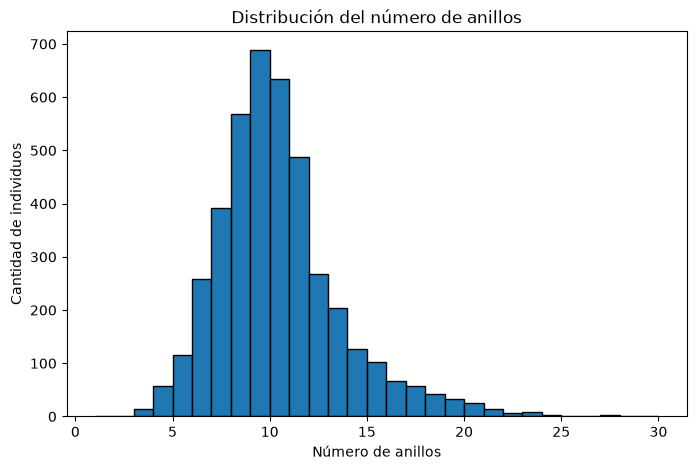

In [818]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_clean["rings"],
    bins=range(1, 31),
    edgecolor="black"
)

plt.title("Distribución del número de anillos")
plt.xlabel("Número de anillos")
plt.ylabel("Cantidad de individuos")

plt.show()

**Conclusión:**  
La distribución de `rings` presenta una concentración principal alrededor de 7 a 12 anillos, con la mayor frecuencia aproximadamente entre 9 y 10.

Se observa una cola hacia los valores altos, por lo que la distribución presenta asimetría positiva (sesgo hacia la derecha).

Esto es coherente con que la media (9.93) sea ligeramente superior a la mediana (9). Los individuos con cantidades elevadas de anillos son menos frecuentes, pero no se consideran automáticamente errores o datos inválidos.

C:\Users\pcbll\AppData\Local\Temp\ipykernel_26216\3802174568.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


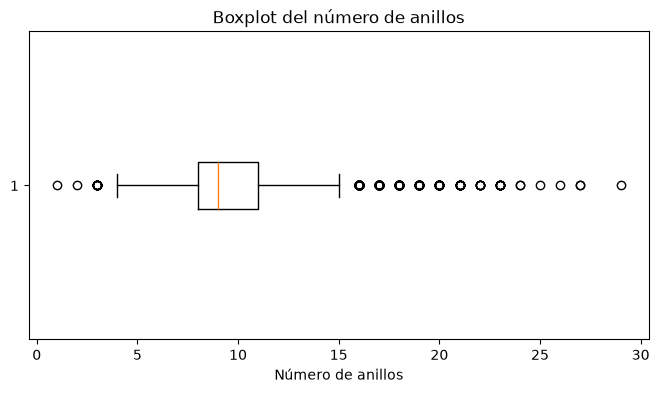

In [819]:
plt.figure(figsize=(8, 4))

plt.boxplot(
    df_clean["rings"],
    vert=False
)

plt.title("Boxplot del número de anillos")
plt.xlabel("Número de anillos")

plt.show()

**Conclusión:**  
El boxplot confirma que la mayor parte de los valores de `rings` se concentra en torno a la mediana de 9 anillos, con el 50% central aproximadamente entre 8 y 11.

Se observan potenciales valores atípicos tanto en el extremo inferior como, principalmente, en el extremo superior de la distribución.

Estos valores no se consideran automáticamente errores, ya que pueden representar individuos biológicamente válidos con cantidades de anillos poco frecuentes. Por lo tanto, no se eliminan en esta etapa.

### 8.2 Exploración de las variables físicas

A continuación se analizan las variables físicas de los abalones para conocer sus distribuciones, detectar posibles valores extremos y comprender qué información podrían aportar posteriormente al modelo de regresión.

Las variables numéricas predictoras son:

- `length`
- `diameter`
- `height`
- `whole_weight`
- `shucked_weight`
- `viscera_weight`
- `shell_weight`

La variable categórica `sex` se analizará por separado.

#### 8.2.1 Longitud (`length`)

Se analiza la distribución de la longitud de los individuos para conocer sus valores centrales, dispersión y rango.

In [820]:
df_clean["length"].describe()

count    4176.000000
mean        0.524042
std         0.120064
min         0.075000
25%         0.450000
50%         0.545000
75%         0.615000
max         0.815000
Name: length, dtype: float64

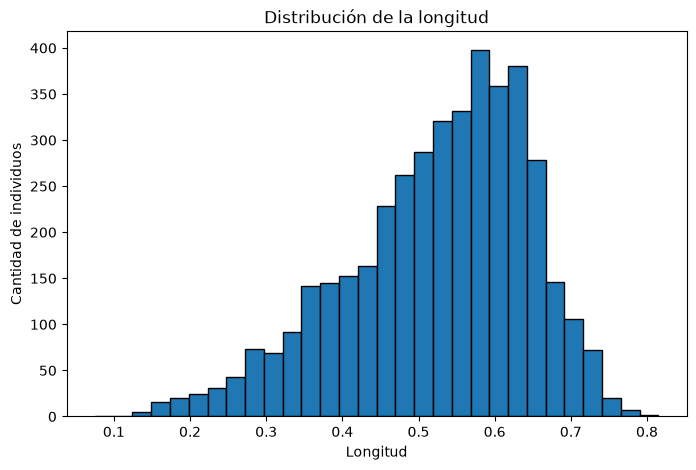

In [821]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_clean["length"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribución de la longitud")
plt.xlabel("Longitud")
plt.ylabel("Cantidad de individuos")

plt.show()

**Conclusión:**  
La distribución de `length` presenta una mayor concentración de individuos aproximadamente entre 0.45 y 0.65.

Se observa una cola hacia los valores bajos, lo que sugiere cierta asimetría negativa (sesgo hacia la izquierda). Esta observación es coherente con que la media (0.524) sea ligeramente menor que la mediana (0.545).

Los valores bajos no se consideran automáticamente anomalías, ya que podrían corresponder a individuos de menor tamaño.

C:\Users\pcbll\AppData\Local\Temp\ipykernel_26216\3501577758.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


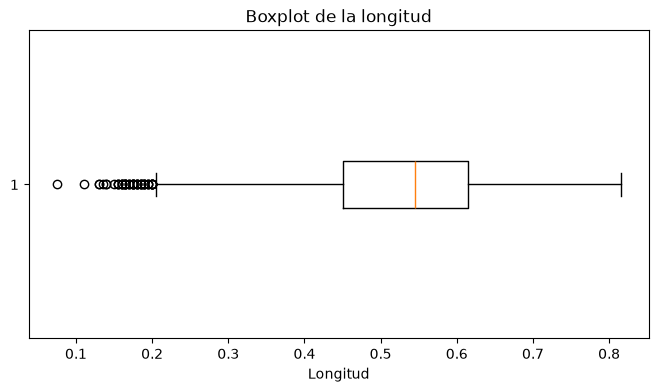

In [822]:
plt.figure(figsize=(8, 4))

plt.boxplot(
    df_clean["length"],
    vert=False
)

plt.title("Boxplot de la longitud")
plt.xlabel("Longitud")

plt.show()

**Conclusión:**  
El boxplot de `length` muestra varios valores potencialmente atípicos en el extremo inferior de la distribución, principalmente por debajo de aproximadamente 0.20.

No se observan valores atípicos equivalentes en el extremo superior.

Estos valores bajos no se eliminan, ya que no presentan por sí mismos una inconsistencia lógica y podrían corresponder a individuos de menor tamaño, particularmente individuos inmaduros (`I`).

Su relación con la categoría `sex` será explorada posteriormente.

#### 8.2.2 Diámetro (`diameter`)

Se analiza la distribución del diámetro de los individuos para conocer sus valores centrales, dispersión y rango.

In [823]:
df_clean["diameter"].describe()

count    4176.000000
mean        0.407924
std         0.099214
min         0.055000
25%         0.350000
50%         0.425000
75%         0.480000
max         0.650000
Name: diameter, dtype: float64

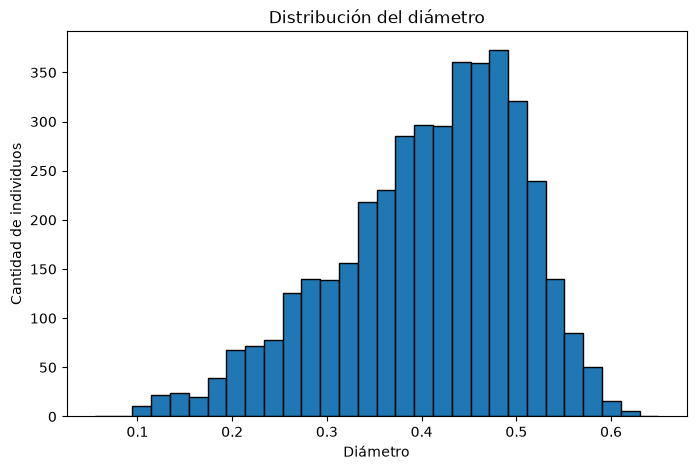

In [824]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_clean["diameter"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribución del diámetro")
plt.xlabel("Diámetro")
plt.ylabel("Cantidad de individuos")

plt.show()

**Conclusión:**  
La distribución de `diameter` presenta una mayor concentración aproximadamente entre 0.35 y 0.52.

Se observa una cola hacia los valores bajos, lo que sugiere cierta asimetría negativa. Esto es coherente con que la media (0.408) sea ligeramente menor que la mediana (0.425).

La forma de la distribución es similar a la observada para `length`, lo que sugiere que ambas variables podrían estar relacionadas por representar dimensiones corporales del mismo individuo. Esta relación se evaluará posteriormente mediante análisis bivariado.

C:\Users\pcbll\AppData\Local\Temp\ipykernel_26216\747618116.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


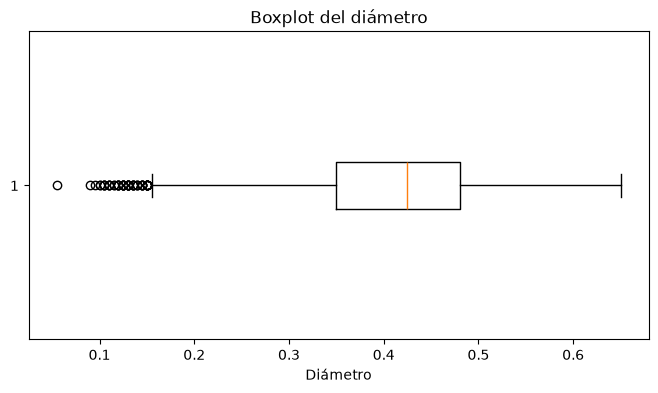

In [825]:
plt.figure(figsize=(8, 4))

plt.boxplot(
    df_clean["diameter"],
    vert=False
)

plt.title("Boxplot del diámetro")
plt.xlabel("Diámetro")

plt.show()

**Conclusión:**  
El boxplot de `diameter` muestra varios valores potencialmente atípicos en el extremo inferior de la distribución.

No se observan valores atípicos importantes en el extremo superior.

Este patrón es similar al observado para `length`, lo que refuerza la posibilidad de que los valores pequeños correspondan a individuos de menor tamaño y no necesariamente a errores de medición.

Estos registros se conservan para análisis posteriores.

#### 8.2.3 Altura (`height`)

Se analiza la distribución de la altura de los individuos luego del tratamiento de las anomalías detectadas previamente.

La variable contiene 2 valores faltantes generados intencionalmente durante la limpieza, correspondientes a registros cuyo valor original se consideró no confiable.

In [826]:
df_clean["height"].describe()

count    4174.000000
mean        0.139346
std         0.038811
min         0.010000
25%         0.115000
50%         0.140000
75%         0.165000
max         0.515000
Name: height, dtype: float64

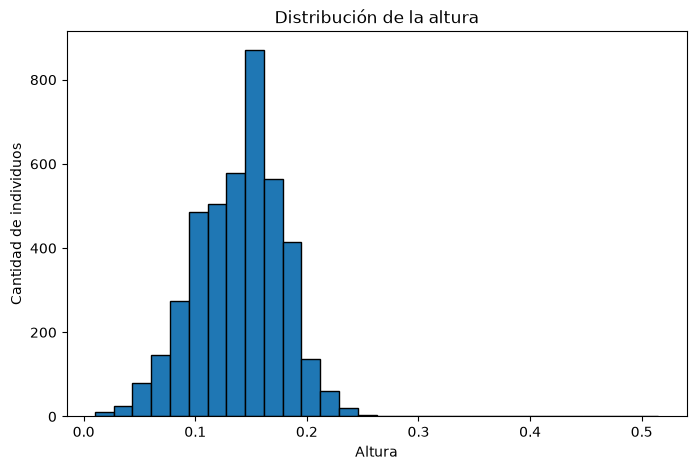

In [827]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_clean["height"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title("Distribución de la altura")
plt.xlabel("Altura")
plt.ylabel("Cantidad de individuos")

plt.show()

**Conclusión:**  
La mayor parte de los valores de `height` se concentra aproximadamente entre 0.05 y 0.25, con una concentración principal alrededor de 0.12–0.18.

La media (0.139) y la mediana (0.140) son prácticamente iguales, por lo que la distribución central no presenta una asimetría marcada.

Sin embargo, se observa un valor de `height = 0.515` claramente separado del resto de la distribución. Este registro se mantiene por el momento, ya que un valor estadísticamente extremo no implica necesariamente un error, aunque deberá considerarse durante el análisis posterior.

C:\Users\pcbll\AppData\Local\Temp\ipykernel_26216\3141799750.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


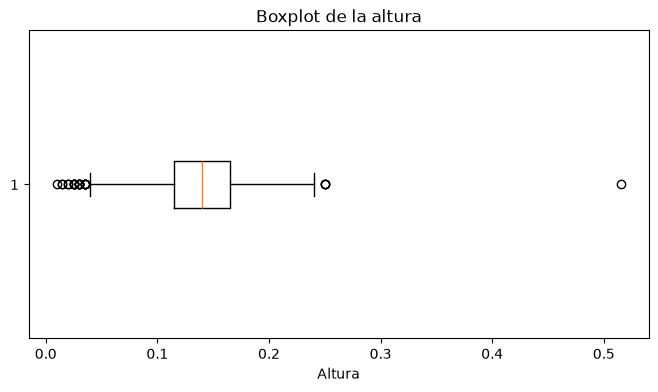

In [828]:
plt.figure(figsize=(8, 4))
plt.boxplot(
    df_clean["height"].dropna(),
    vert=False
)
plt.title("Boxplot de la altura")
plt.xlabel("Altura")
plt.show()

**Conclusión:**  
El boxplot de `height` muestra varios valores potencialmente atípicos en los extremos de la distribución.

El valor `0.515` destaca especialmente por encontrarse muy separado del resto de las observaciones. También se observan algunos valores bajos y un valor cercano a `0.25` identificados como potenciales outliers según el criterio del boxplot.

Estos valores se conservan, ya que ser estadísticamente atípico no implica necesariamente que sean errores. El valor `0.515` será tenido en cuenta durante los análisis posteriores.

#### 8.2.4 Peso total (`whole_weight`)

Se analiza la distribución del peso total de los individuos para conocer sus valores centrales, dispersión y rango.

In [829]:
df_clean["whole_weight"].describe()

count    4176.000000
mean        0.828909
std         0.490330
min         0.002000
25%         0.441875
50%         0.799750
75%         1.153250
max         2.825500
Name: whole_weight, dtype: float64

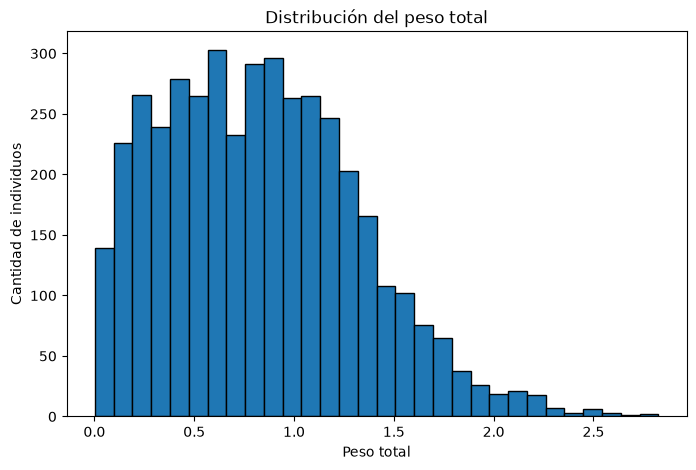

In [830]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_clean["whole_weight"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribución del peso total")
plt.xlabel("Peso total")
plt.ylabel("Cantidad de individuos")

plt.show()

**Conclusión:**  
La distribución de `whole_weight` presenta una concentración principal en los valores bajos e intermedios, mientras que la frecuencia disminuye progresivamente hacia los pesos más elevados.

Se observa una cola hacia valores altos, indicando asimetría positiva (sesgo hacia la derecha). Esto es coherente con que la media (0.829) sea ligeramente superior a la mediana (0.800).

Los individuos con pesos elevados son menos frecuentes, pero no se consideran automáticamente anomalías. La distribución también podría estar influida por diferencias entre las categorías de `sex`, lo cual será evaluado posteriormente.

C:\Users\pcbll\AppData\Local\Temp\ipykernel_26216\3575977817.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


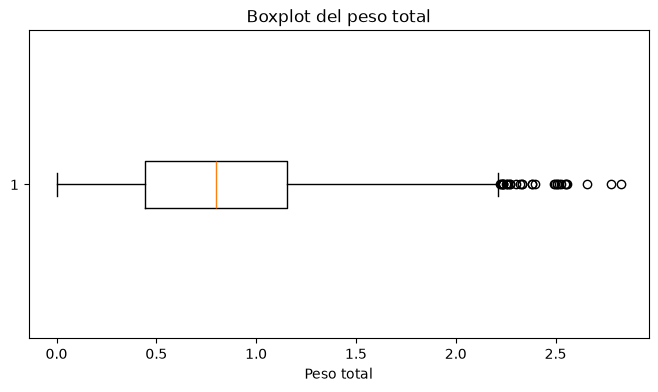

In [831]:
plt.figure(figsize=(8, 4))

plt.boxplot(
    df_clean["whole_weight"],
    vert=False
)

plt.title("Boxplot del peso total")
plt.xlabel("Peso total")

plt.show()

**Conclusión:**  
El boxplot de `whole_weight` muestra varios valores potencialmente atípicos en el extremo superior de la distribución, principalmente a partir de valores cercanos a 2.2.

Este patrón es coherente con la asimetría positiva observada en el histograma.

Los individuos con pesos elevados se conservan, ya que no presentan por sí mismos una inconsistencia lógica y podrían representar variabilidad biológica real.

#### 8.2.5 Peso de la carne (`shucked_weight`)

Se analiza la distribución del peso de la carne de los individuos para conocer sus valores centrales, dispersión y rango.

In [832]:
df_clean["shucked_weight"].describe()

count    4176.000000
mean        0.359440
std         0.221940
min         0.001000
25%         0.186375
50%         0.336000
75%         0.502000
max         1.488000
Name: shucked_weight, dtype: float64

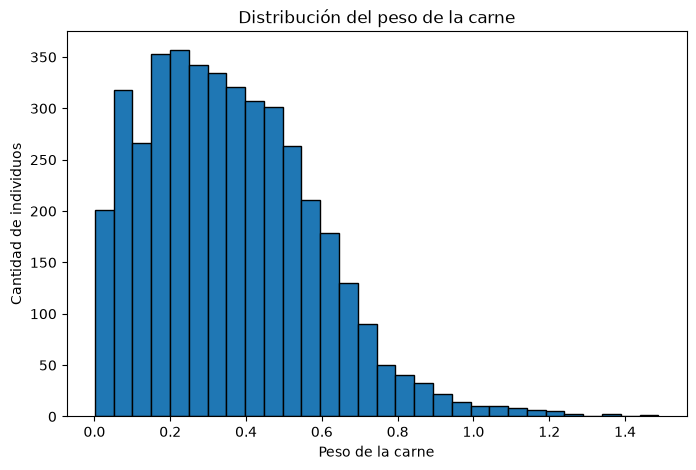

In [833]:
plt.figure(figsize=(8, 5))
plt.hist(
    df_clean["shucked_weight"],
    bins=30,
    edgecolor="black"
)
plt.title("Distribución del peso de la carne")
plt.xlabel("Peso de la carne")
plt.ylabel("Cantidad de individuos")
plt.show()

**Conclusión:**  
La distribución de `shucked_weight` presenta una mayor concentración en valores bajos e intermedios y una cola progresiva hacia valores altos.

Se observa asimetría positiva (sesgo hacia la derecha), coherente con que la media (0.359) sea superior a la mediana (0.336).

Los individuos con valores elevados de peso de la carne son menos frecuentes, pero no se consideran automáticamente anomalías y se conservan para los análisis posteriores.

C:\Users\pcbll\AppData\Local\Temp\ipykernel_26216\4053021183.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


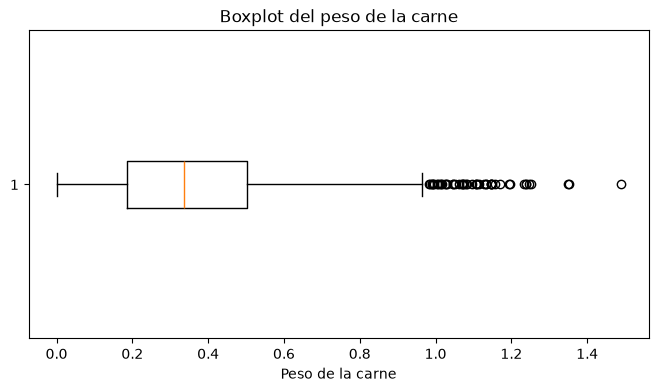

In [834]:
plt.figure(figsize=(8, 4))
plt.boxplot(
    df_clean["shucked_weight"],
    vert=False
)
plt.title("Boxplot del peso de la carne")
plt.xlabel("Peso de la carne")
plt.show()

**Conclusión:**  
El boxplot de `shucked_weight` muestra varios valores potencialmente atípicos en el extremo superior de la distribución, principalmente a partir de valores cercanos a 0.98.

Este patrón es coherente con la asimetría positiva observada en el histograma.

Los valores altos se conservan, ya que no presentan una inconsistencia lógica y pueden representar variabilidad biológica real.

#### 8.2.6 Peso de las vísceras (`viscera_weight`)

Se analiza la distribución del peso de las vísceras de los individuos para conocer sus valores centrales, dispersión y rango.

In [835]:
df_clean["viscera_weight"].describe()

count    4176.000000
mean        0.180630
std         0.109602
min         0.000500
25%         0.093500
50%         0.171000
75%         0.253000
max         0.760000
Name: viscera_weight, dtype: float64

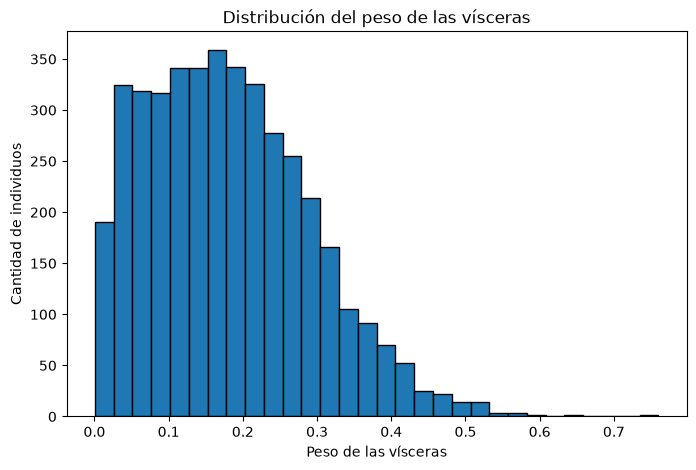

In [836]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_clean["viscera_weight"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribución del peso de las vísceras")
plt.xlabel("Peso de las vísceras")
plt.ylabel("Cantidad de individuos")

plt.show()

**Conclusión:**  
La distribución de `viscera_weight` presenta una mayor concentración en valores bajos e intermedios y una cola progresiva hacia valores elevados.

Se observa asimetría positiva (sesgo hacia la derecha), coherente con que la media (0.181) sea ligeramente superior a la mediana (0.171).

Los individuos con valores elevados de peso de las vísceras son poco frecuentes, pero no presentan por sí mismos una inconsistencia lógica, por lo que se conservan para los análisis posteriores.

C:\Users\pcbll\AppData\Local\Temp\ipykernel_26216\610956775.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


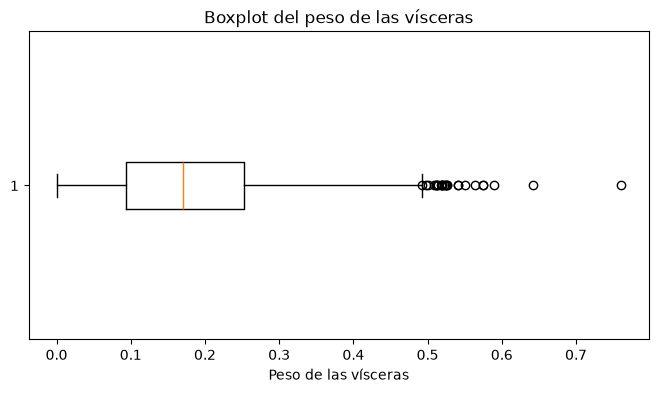

In [837]:
plt.figure(figsize=(8, 4))

plt.boxplot(
    df_clean["viscera_weight"],
    vert=False
)

plt.title("Boxplot del peso de las vísceras")
plt.xlabel("Peso de las vísceras")

plt.show()

**Conclusión:**  
El boxplot de `viscera_weight` muestra varios valores potencialmente atípicos en el extremo superior de la distribución, principalmente a partir de valores cercanos a 0.49.

Este patrón coincide con la asimetría positiva observada previamente en el histograma.

Los valores elevados se conservan, ya que no presentan una inconsistencia lógica y podrían representar variabilidad biológica real entre los individuos.

#### 8.2.7 Peso de la concha (`shell_weight`)

Se analiza la distribución del peso de la concha de los individuos para conocer sus valores centrales, dispersión y rango.

In [838]:
df_clean["shell_weight"].describe()

count    4176.000000
mean        0.238804
std         0.139209
min         0.001500
25%         0.130000
50%         0.233750
75%         0.328625
max         1.005000
Name: shell_weight, dtype: float64

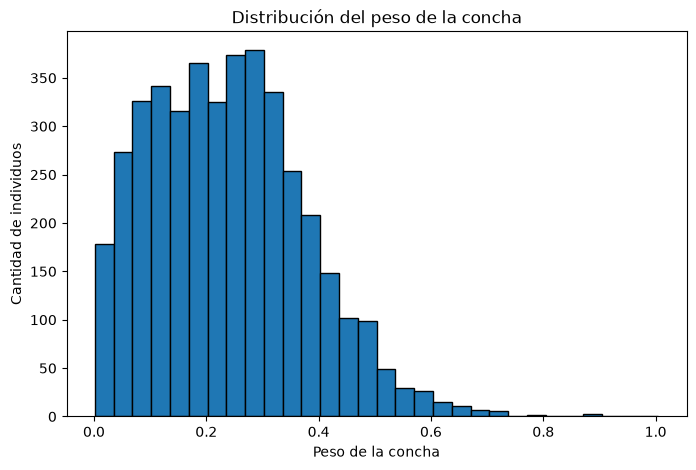

In [839]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_clean["shell_weight"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribución del peso de la concha")
plt.xlabel("Peso de la concha")
plt.ylabel("Cantidad de individuos")

plt.show()

**Conclusión:**  
La distribución de `shell_weight` presenta una mayor concentración en valores bajos e intermedios y una cola hacia valores elevados.

Se observa asimetría positiva (sesgo hacia la derecha), aunque la media (0.239) y la mediana (0.234) se encuentran bastante próximas.

Existen algunos individuos con pesos de concha elevados y poco frecuentes. Estos valores no se consideran automáticamente errores y se conservan para los análisis posteriores.

C:\Users\pcbll\AppData\Local\Temp\ipykernel_26216\3567227075.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


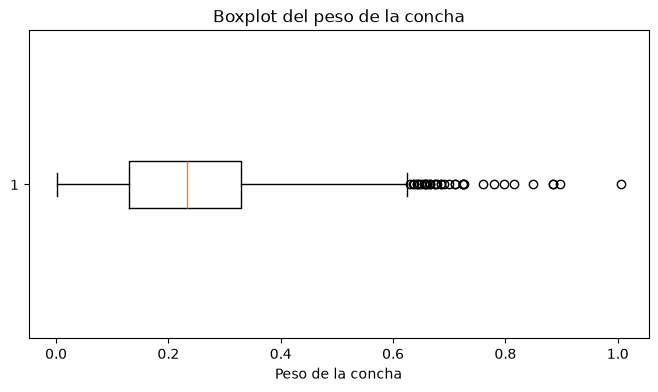

In [840]:
plt.figure(figsize=(8, 4)) 
plt.boxplot(
    df_clean["shell_weight"],
    vert=False
)
plt.title("Boxplot del peso de la concha")
plt.xlabel("Peso de la concha")
plt.show()

**Conclusión:**  
El boxplot de `shell_weight` muestra varios valores potencialmente atípicos en el extremo superior de la distribución, principalmente a partir de valores cercanos a 0.62.

Este patrón coincide con la asimetría positiva observada en el histograma.

Los valores elevados se conservan, ya que no presentan una inconsistencia lógica y pueden representar variabilidad biológica real entre los individuos.

### 8.3 Exploración de la variable categórica `sex`

La variable `sex` clasifica a los individuos en tres categorías.

A diferencia de las variables numéricas, esta variable se analiza mediante frecuencias y proporciones para conocer cómo están representadas sus categorías en el dataset.

In [841]:
df_clean["sex"].value_counts()

sex
M    1528
I    1341
F    1307
Name: count, dtype: int64

In [842]:
df_clean["sex"].value_counts(normalize=True) * 100

sex
M    36.590038
I    32.112069
F    31.297893
Name: proportion, dtype: float64

**Conclusión:**  
La variable `sex` presenta una distribución relativamente equilibrada entre sus tres categorías.

- `M`: aproximadamente 36.59 % de los individuos.
- `I`: aproximadamente 32.11 %.
- `F`: aproximadamente 31.30 %.

Aunque `M` es la categoría más frecuente, ninguna categoría domina ampliamente el dataset, por lo que los tres grupos cuentan con una representación considerable para los análisis posteriores.

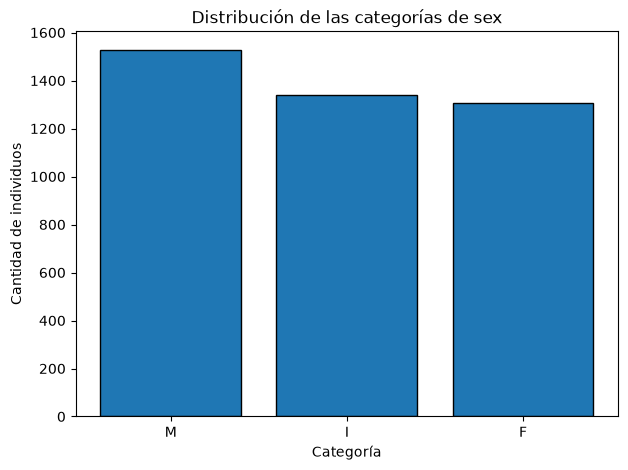

In [843]:
sex_counts = df_clean["sex"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    sex_counts.index,
    sex_counts.values,
    edgecolor="black"
)

plt.title("Distribución de las categorías de sex")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de individuos")

plt.show()

**Conclusión:**  
El gráfico de barras confirma que las tres categorías de `sex` presentan una representación relativamente equilibrada en el dataset.

La categoría `M` es la más frecuente, seguida por `I` y `F`, aunque las diferencias entre los tres grupos no son marcadas.

Por lo tanto, no se observa un desbalance importante entre las categorías.

## 8.4 Análisis bivariado

Luego de estudiar cada variable por separado, se analizan las relaciones entre pares de variables.

El objetivo es identificar asociaciones entre las características físicas de los abalones y evaluar cuáles podrían aportar información para predecir la variable objetivo `rings`.

Primero se explorará la relación entre distintas medidas corporales y posteriormente su relación con `rings`.

### 8.4.1 Matriz de correlación de variables numéricas

Como primera aproximación a las relaciones entre variables, se calcula una matriz de correlación.

Esta permite observar de forma conjunta la dirección y la intensidad de las relaciones lineales entre las variables numéricas e identificar asociaciones que luego serán exploradas mediante gráficos específicos.

In [844]:
corr_matrix = df_clean.corr(numeric_only=True)

corr_matrix

,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
length,1.000000,0.986802,0.893949,0.925229,0.897871,0.902975,0.898435,0.556512
diameter,0.986802,1.000000,0.900346,0.925422,0.893120,0.899682,0.906093,0.574460
height,0.893949,0.900346,1.000000,0.884511,0.834719,0.862643,0.885932,0.603264
whole_weight,0.925229,0.925422,0.884511,1.000000,0.969392,0.966359,0.955931,0.540202
shucked_weight,0.897871,0.893120,0.834719,0.969392,1.000000,0.931931,0.883142,0.420654
viscera_weight,0.902975,0.899682,0.862643,0.966359,0.931931,1.000000,0.908202,0.503620
shell_weight,0.898435,0.906093,0.885932,0.955931,0.883142,0.908202,1.000000,0.627969
rings,0.556512,0.574460,0.603264,0.540202,0.420654,0.503620,0.627969,1.000000


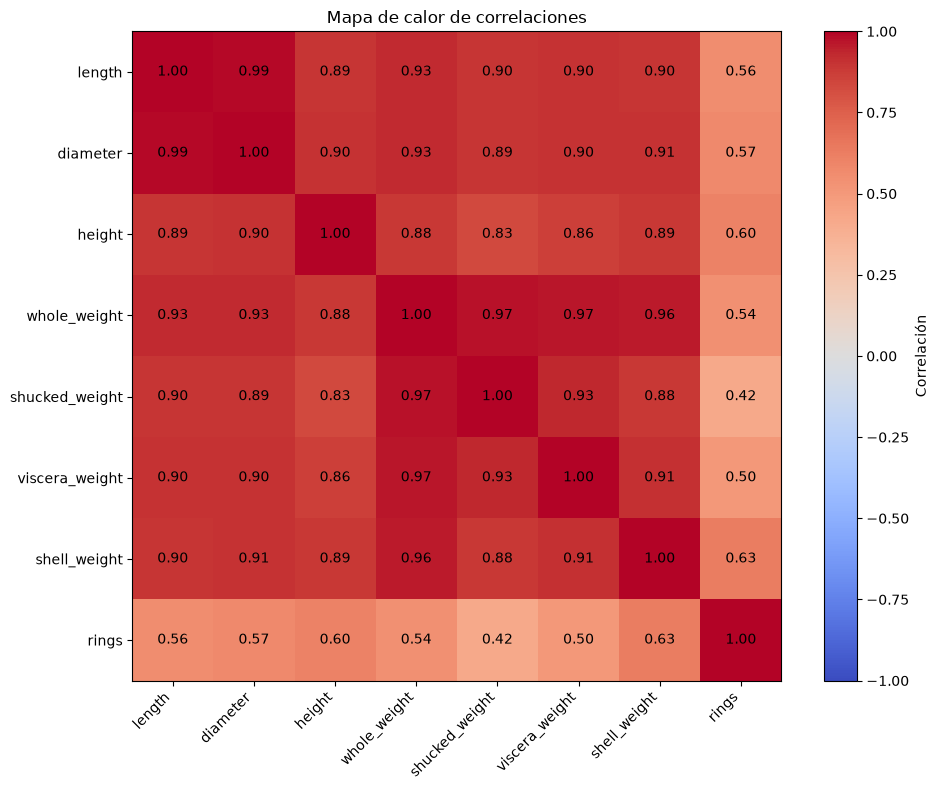

In [845]:
plt.figure(figsize=(10, 8))

plt.imshow(
    corr_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlación")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr_matrix.index)),
    corr_matrix.index
)

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Mapa de calor de correlaciones")

plt.tight_layout()
plt.show()

**Conclusión:**  
La matriz de correlación muestra asociaciones positivas entre todas las variables numéricas analizadas.

Las variables que representan dimensiones y pesos corporales presentan correlaciones muy elevadas entre sí. Destacan especialmente `length` con `diameter` (≈ 0.99) y `whole_weight` con las distintas variables de peso (≈ 0.96–0.97).

Respecto de la variable objetivo `rings`, la mayor correlación lineal se observa con `shell_weight` (≈ 0.63), seguida por `height` (≈ 0.60), `diameter` (≈ 0.57) y `length` (≈ 0.56).

Estas relaciones sugieren que las características físicas contienen información útil para predecir `rings`. Sin embargo, las elevadas correlaciones entre varias variables predictoras indican que existe información redundante entre ellas, aspecto que deberá considerarse durante el modelado.

### 8.4.2 Relación de las variables físicas con `rings`

Luego de analizar las correlaciones, se explora gráficamente la relación entre las características físicas de los abalones y la variable objetivo `rings`.

El objetivo es observar qué patrones presentan estas variables respecto al número de anillos y evaluar cuáles podrían aportar información útil para su predicción.

Se comenzará con `shell_weight`, ya que fue la variable numérica que presentó la mayor correlación lineal con `rings` (r ≈ 0.63).

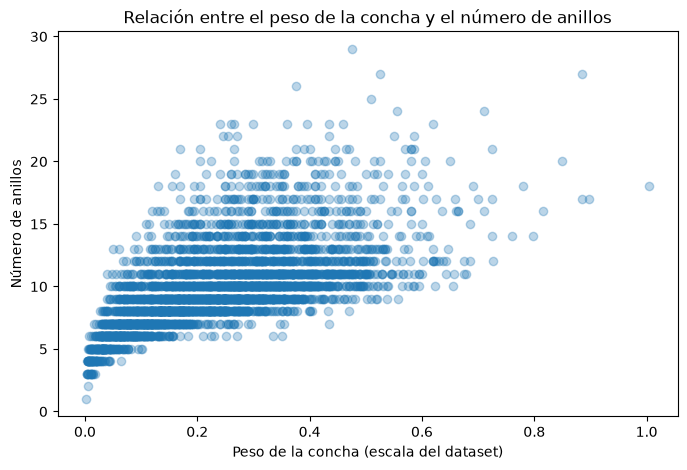

In [846]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df_clean["shell_weight"],
    df_clean["rings"],
    alpha=0.3
)
plt.title("Relación entre el peso de la concha y el número de anillos")
plt.xlabel("Peso de la concha (escala del dataset)")
plt.ylabel("Número de anillos")
plt.show()

**Conclusión:**  
El diagrama de dispersión muestra una asociación positiva entre `shell_weight` y `rings`: en términos generales, los individuos con mayores valores de peso de la concha tienden a presentar un mayor número de anillos.

Sin embargo, existe una dispersión considerable de los datos, por lo que `shell_weight` por sí sola no permite determinar con precisión el número de anillos.

Esto coincide con la correlación positiva moderada observada previamente (r ≈ 0.63) y sugiere que será necesario combinar varias características físicas para mejorar la capacidad predictiva del modelo.

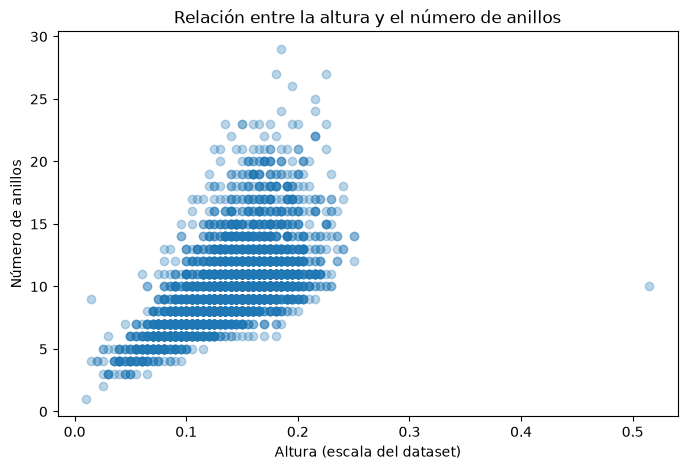

In [847]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df_clean["height"],
    df_clean["rings"],
    alpha=0.3
)
plt.title("Relación entre la altura y el número de anillos")
plt.xlabel("Altura (escala del dataset)") 
plt.ylabel("Número de anillos")
plt.show()

**Conclusión:**  
El diagrama de dispersión muestra una asociación positiva entre `height` y `rings`. En general, los individuos con mayores valores de altura tienden a presentar un mayor número de anillos.

La relación presenta dispersión, por lo que `height` tampoco permite predecir por sí sola el número de anillos. Esto es consistente con la correlación positiva moderada observada previamente (r ≈ 0.60).

También se observa un valor extremo de `height` cercano a 0.51, previamente identificado durante el análisis de calidad de datos y conservado al no encontrarse evidencia suficiente para considerarlo un error.

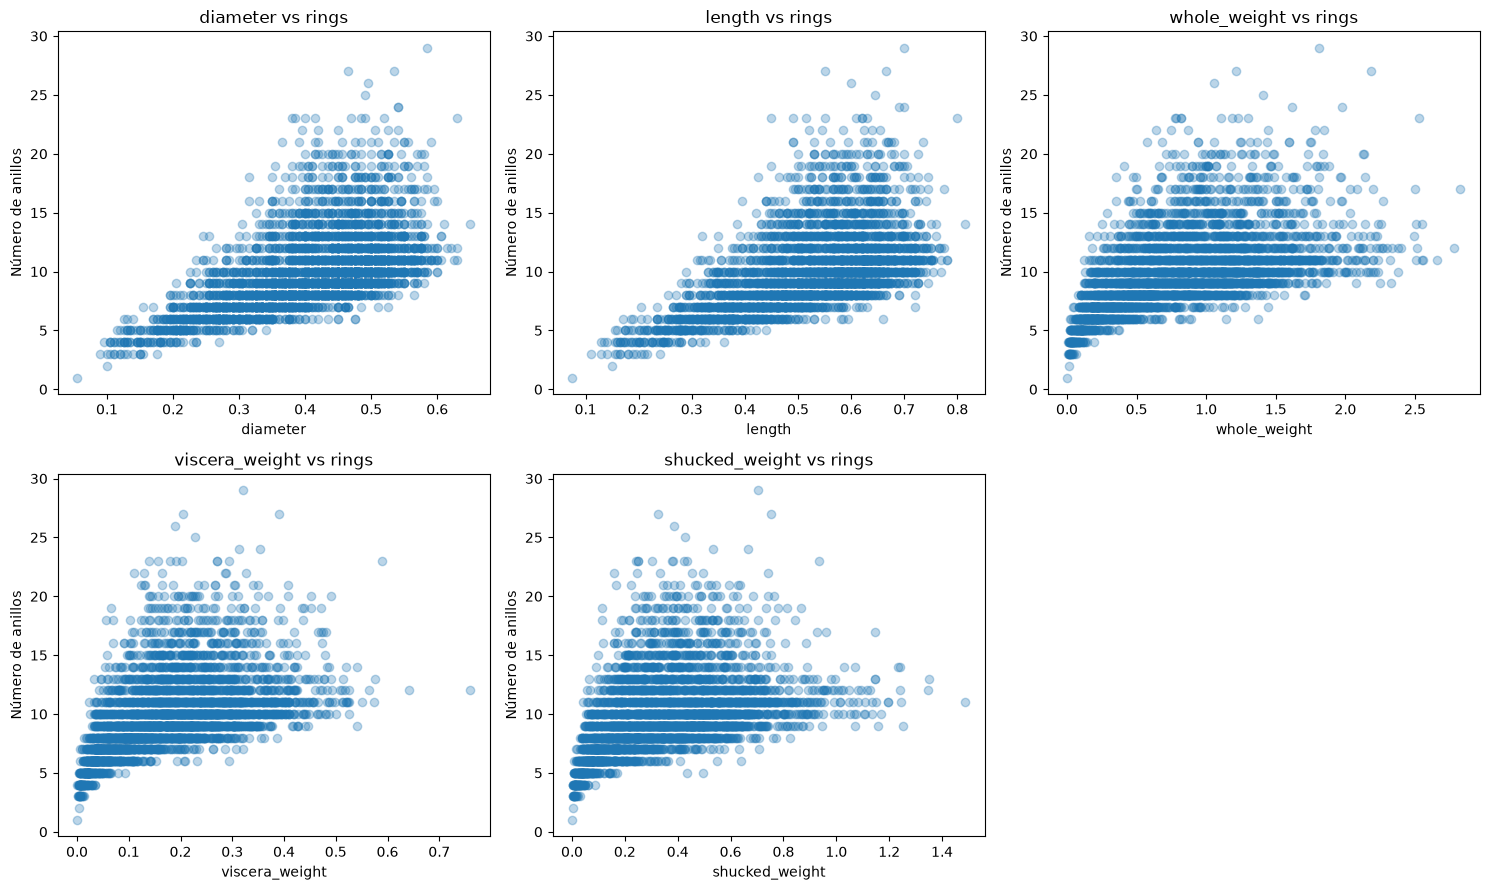

In [848]:
variables = [
    "diameter",
    "length",
    "whole_weight",
    "viscera_weight",
    "shucked_weight"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes = axes.flatten()

for i, variable in enumerate(variables):
    axes[i].scatter(
        df_clean[variable],
        df_clean["rings"],
        alpha=0.3
    )

    axes[i].set_title(f"{variable} vs rings")
    axes[i].set_xlabel(variable)
    axes[i].set_ylabel("Número de anillos")

# El sexto espacio queda vacío
axes[5].axis("off")

plt.tight_layout()
plt.show()

**Conclusión:**  
Los diagramas de dispersión muestran que las variables físicas restantes presentan, en general, asociaciones positivas con `rings`.

`diameter` y `length` muestran patrones positivos relativamente claros, mientras que las variables de peso presentan una mayor dispersión. Entre estas últimas, `shucked_weight` muestra la asociación visual más débil con el número de anillos.

En conjunto, los gráficos sugieren que ninguna característica física individual permite explicar completamente `rings`, por lo que la combinación de múltiples variables podría aportar una mejor capacidad predictiva durante el modelado.

### 8.4.3 Relación entre `sex` y `rings`

La variable `sex` es categórica, por lo que su relación con `rings` se analiza comparando la distribución del número de anillos entre sus distintas categorías.

In [849]:
df_clean.groupby("sex")["rings"].describe()

,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
F,1307.0,11.129304,3.104256,5.0,9.0,10.0,12.0,29.0
I,1341.0,7.891872,2.511960,1.0,6.0,8.0,9.0,21.0
M,1528.0,10.705497,3.026349,3.0,9.0,10.0,12.0,27.0


**Conclusión:**  
La distribución de `rings` presenta diferencias entre las categorías de `sex`.

Las categorías `F` y `M` muestran valores centrales similares, con medianas de 10 anillos y medias cercanas a 11 y 10.7, respectivamente.

En cambio, la categoría `I` presenta valores menores de `rings`, con una media aproximada de 7.9 y una mediana de 8.

Esto sugiere que la variable categórica `sex` contiene información potencialmente útil para la predicción de `rings`, especialmente por la diferencia observada entre la categoría `I` y las categorías `F` y `M`.

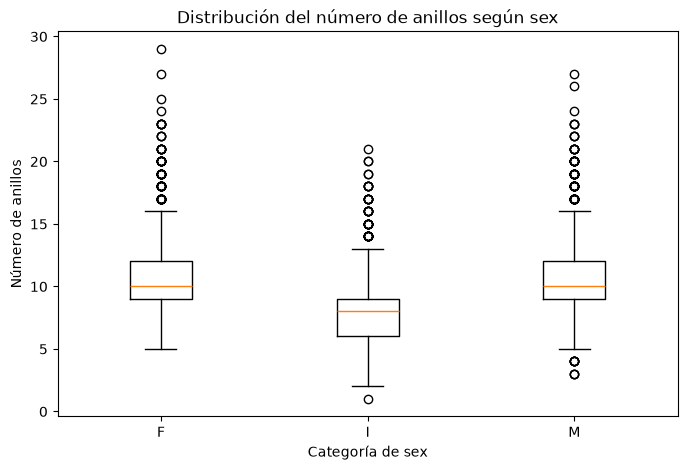

In [850]:
groups = [
    df_clean.loc[df_clean["sex"] == "F", "rings"],
    df_clean.loc[df_clean["sex"] == "I", "rings"],
    df_clean.loc[df_clean["sex"] == "M", "rings"]
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    groups,
    tick_labels=["F", "I", "M"]
)

plt.title("Distribución del número de anillos según sex")
plt.xlabel("Categoría de sex")
plt.ylabel("Número de anillos")

plt.show()

**Conclusión:**  
El boxplot confirma que la distribución de `rings` difiere entre las categorías de `sex`.

Las categorías `F` y `M` presentan distribuciones similares, con medianas cercanas a 10 anillos. En cambio, la categoría `I` se encuentra desplazada hacia valores menores, con una mediana cercana a 8 anillos.

Aunque existe superposición entre las distribuciones, la diferencia observada en la categoría `I` indica que `sex` puede aportar información útil al modelo para predecir `rings`.

También se observan valores potencialmente atípicos en los tres grupos, principalmente en el extremo superior de la distribución.

## 9. Preparación de los datos para Machine Learning

Una vez finalizado el análisis exploratorio, se preparan los datos que serán utilizados para entrenar los modelos predictivos.

La variable objetivo será `rings`, mientras que las restantes características físicas y la variable categórica `sex` se utilizarán como variables predictoras.

- **Variable objetivo (`y`):** `rings`
- **Variables predictoras (`X`):** `sex`, `length`, `diameter`, `height`, `whole_weight`, `shucked_weight`, `viscera_weight` y `shell_weight`.

El objetivo será utilizar estas características para predecir el número de anillos de cada individuo.

In [851]:
X = df_clean.drop(columns="rings")
y = df_clean["rings"]

In [852]:
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

print("\nColumnas de X:")
print(X.columns.tolist())

print("\nNombre de y:")
print(y.name)

Dimensiones de X: (4176, 8)
Dimensiones de y: (4176,)

Columnas de X:
['sex', 'length', 'diameter', 'height', 'whole_weight', 'shucked_weight', 'viscera_weight', 'shell_weight']

Nombre de y:
rings


### 9.1 División en conjuntos de entrenamiento y prueba

Antes de realizar el preprocesamiento y entrenar los modelos, los datos se dividen en un conjunto de entrenamiento (`train`) y un conjunto de prueba (`test`).

El conjunto de entrenamiento se utilizará para ajustar y validar los modelos, mientras que el conjunto de prueba se reservará para realizar una evaluación final sobre datos que el modelo no haya utilizado durante el aprendizaje.

Esta separación se realiza antes del preprocesamiento para evitar que información del conjunto de prueba influya en el entrenamiento del modelo.

In [853]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [854]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3340, 8)
X_test: (836, 8)
y_train: (3340,)
y_test: (836,)


### 9.2 Preprocesamiento de las variables

Antes de entrenar los modelos es necesario transformar las variables para que puedan ser utilizadas correctamente por los algoritmos de Machine Learning.

El dataset contiene dos tipos de predictores:

- **Variables numéricas:** `length`, `diameter`, `height`, `whole_weight`, `shucked_weight`, `viscera_weight` y `shell_weight`.
- **Variable categórica:** `sex`.

Las variables numéricas y categóricas requerirán tratamientos diferentes. Además, los valores faltantes de `height` deberán ser imputados.

Estas transformaciones se realizarán mediante un pipeline de scikit-learn, ajustado únicamente con los datos de entrenamiento para evitar fuga de información (`data leakage`).

In [855]:
numeric_features = [
    "length",
    "diameter",
    "height",
    "whole_weight",
    "shucked_weight",
    "viscera_weight",
    "shell_weight"
]

categorical_features = [
    "sex"
]

In [856]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [857]:
categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [858]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 10. Modelado predictivo

Una vez definido el preprocesamiento, se inicia la etapa de construcción y evaluación de modelos para predecir `rings`.

Los modelos serán evaluados utilizando únicamente el conjunto de entrenamiento mediante validación cruzada. El conjunto de prueba permanecerá reservado para la evaluación final.

Como primer paso se construirá un modelo baseline, que servirá como referencia para determinar si los modelos posteriores realmente aportan capacidad predictiva.

In [859]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyRegressor(strategy="mean"))
    ]
)

In [860]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

mae_scores = -cross_val_score(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring="neg_mean_absolute_error"
)

print("MAE por fold:", mae_scores)
print("MAE promedio:", mae_scores.mean())

MAE por fold: [2.30738598 2.30358968 2.47005988 2.30449617 2.3974282 ]
MAE promedio: 2.35659198070924


### 10.1 Evaluación del modelo baseline

El modelo baseline fue evaluado mediante validación cruzada de 5 particiones utilizando únicamente el conjunto de entrenamiento.

Se obtuvo un MAE promedio de aproximadamente **2.36 anillos**.

Esto significa que una estrategia extremadamente simple, basada en predecir la media de `rings`, presenta un error absoluto promedio cercano a 2.36 anillos.

Este resultado se utilizará como punto de referencia: los modelos predictivos posteriores deberán obtener un MAE menor para demostrar que están aprendiendo información útil a partir de las características de los individuos.

In [861]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

### 10.2 Regresión lineal

Como primer modelo predictivo se utiliza una regresión lineal.

El modelo se evaluará mediante validación cruzada de 5 particiones utilizando el conjunto de entrenamiento y el MAE como métrica de error.

El resultado se comparará con el modelo baseline, cuyo MAE promedio fue de aproximadamente 2.36 anillos.

In [862]:
linear_mae_scores = -cross_val_score(
    linear_model,
    X_train,
    y_train,
    cv=cv,
    scoring="neg_mean_absolute_error"
)

print("MAE por fold:", linear_mae_scores)
print("MAE promedio:", linear_mae_scores.mean())

MAE por fold: [1.58683638 1.64418816 1.585186   1.57136569 1.51622931]
MAE promedio: 1.580761106246755


**Conclusión:**  
La regresión lineal obtuvo un MAE promedio de aproximadamente **1.58 anillos**, frente a un MAE de aproximadamente **2.36 anillos** obtenido por el modelo baseline.

Esto indica que la regresión lineal logra aprovechar la información contenida en las características físicas y en la variable `sex` para realizar predicciones considerablemente mejores que una estrategia basada únicamente en la media de `rings`.

Los valores de MAE obtenidos en los distintos folds fueron relativamente similares, lo que sugiere un comportamiento estable del modelo entre las diferentes particiones de entrenamiento y validación.

### 10.3 Random Forest Regressor

Como segundo modelo predictivo se utiliza un `RandomForestRegressor`.

A diferencia de la regresión lineal, Random Forest puede capturar relaciones no lineales e interacciones más complejas entre las variables predictoras.

El modelo se evaluará mediante la misma validación cruzada de 5 particiones y utilizando el MAE como métrica, para poder compararlo de forma justa con el baseline y con la regresión lineal.

In [863]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [864]:
random_forest_mae_scores = -cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring="neg_mean_absolute_error"
)

print("MAE por fold:", random_forest_mae_scores)
print("MAE promedio:", random_forest_mae_scores.mean())

MAE por fold: [1.60998503 1.53486527 1.59826347 1.49534431 1.46799401]
MAE promedio: 1.5412904191616765


**Conclusión:**  
El modelo Random Forest obtuvo un MAE promedio de aproximadamente **1.54 anillos** mediante validación cruzada de 5 particiones.

Este resultado mejora considerablemente al modelo baseline (MAE ≈ 2.36) y presenta una mejora leve respecto de la regresión lineal (MAE ≈ 1.58).

La diferencia entre Random Forest y regresión lineal es relativamente pequeña, lo que indica que el aumento en la complejidad del modelo produce una mejora predictiva limitada en esta etapa.

Los valores obtenidos en los distintos folds fueron relativamente similares, lo que sugiere un comportamiento estable del modelo entre las diferentes particiones de entrenamiento y validación.

### 10.4 Gradient Boosting Regressor

Como tercer modelo predictivo se utiliza un `GradientBoostingRegressor`.

Este algoritmo construye una secuencia de árboles de decisión, donde cada nuevo árbol intenta corregir parte de los errores cometidos por los árboles anteriores.

Al igual que los modelos previos, se evaluará mediante validación cruzada de 5 particiones utilizando el conjunto de entrenamiento y el MAE como métrica.

Esto permitirá comparar su desempeño de forma justa con el baseline, la regresión lineal y Random Forest.

In [865]:
gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            random_state=42
        ))
    ]
)

In [866]:
gradient_boosting_mae_scores = -cross_val_score(
    gradient_boosting_model,
    X_train,
    y_train,
    cv=cv,
    scoring="neg_mean_absolute_error"
)

print("MAE por fold:", gradient_boosting_mae_scores)
print("MAE promedio:", gradient_boosting_mae_scores.mean())

MAE por fold: [1.56083458 1.50792044 1.56726849 1.50062186 1.45334646]
MAE promedio: 1.5179983652502809


**Conclusión:**  
El modelo Gradient Boosting obtuvo un MAE promedio de aproximadamente **1.52 anillos** mediante validación cruzada de 5 particiones.

Este resultado supera al modelo baseline (MAE ≈ 2.36), a la regresión lineal (MAE ≈ 1.58) y presenta una mejora leve respecto de Random Forest (MAE ≈ 1.54).

Por lo tanto, Gradient Boosting presenta hasta el momento el menor error predictivo entre los modelos evaluados.

Sin embargo, la diferencia respecto de Random Forest es pequeña, por lo que ambos modelos muestran un desempeño similar. La selección definitiva se realizará mediante una comparación conjunta de todos los modelos antes de utilizar el conjunto de prueba final.

### 10.5 Comparación final de modelos

Luego de evaluar todos los modelos mediante validación cruzada de 5 particiones, se comparan sus valores de MAE promedio.

Esta comparación permite identificar cuál de los modelos presenta el menor error predictivo utilizando únicamente los datos de entrenamiento y validación.

Los modelos evaluados fueron:

- Baseline
- Regresión lineal
- Random Forest
- Gradient Boosting

Como el MAE representa el error absoluto promedio, valores más bajos indican un mejor desempeño predictivo.

In [867]:
model_results = pd.DataFrame({
    "Modelo": [
        "Baseline",
        "Regresión lineal",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE_promedio": [
        mae_scores.mean(),
        linear_mae_scores.mean(),
        random_forest_mae_scores.mean(),
        gradient_boosting_mae_scores.mean()
    ]
})

model_results = model_results.sort_values(
    by="MAE_promedio"
).reset_index(drop=True)

model_results

,Modelo,MAE_promedio
0,Gradient Boosting,1.517998
1,Random Forest,1.541290
2,Regresión lineal,1.580761
3,Baseline,2.356592


**Conclusión:**  
La comparación final muestra que los tres modelos predictivos superan ampliamente al modelo baseline.

`Gradient Boosting` obtuvo el menor MAE promedio (≈ 1.52 anillos), seguido por `Random Forest` (≈ 1.54) y la regresión lineal (≈ 1.58). El baseline presentó un MAE considerablemente mayor (≈ 2.36).

Por lo tanto, `Gradient Boosting` presenta el mejor desempeño durante la validación cruzada y se selecciona como el principal candidato para la evaluación final.

Sin embargo, las diferencias entre Gradient Boosting, Random Forest y regresión lineal son relativamente pequeñas. Por este motivo, el resultado final deberá comprobarse utilizando el conjunto de prueba, que permaneció separado durante todo el proceso de entrenamiento y selección de modelos.

### 10.6 Evaluación final del modelo seleccionado

Luego de comparar los modelos mediante validación cruzada, `Gradient Boosting` fue seleccionado como el modelo con mejor desempeño, al obtener el menor MAE promedio.

A continuación, el modelo se entrenará utilizando todo el conjunto de entrenamiento (`X_train`, `y_train`) y posteriormente se evaluará sobre el conjunto de prueba (`X_test`, `y_test`).

El conjunto de prueba no fue utilizado durante el entrenamiento ni durante la selección de modelos, por lo que permitirá estimar el desempeño del modelo sobre datos no vistos previamente.

In [868]:
gradient_boosting_model.fit(
    X_train,
    y_train
);

In [869]:
y_pred = gradient_boosting_model.predict(X_test)

print("Primeras 10 predicciones:")
print(y_pred[:10])

print("\nPrimeros 10 valores reales:")
print(y_test.iloc[:10].values)

Primeras 10 predicciones:
[11.71244183 10.04528475 15.46394766 11.00135399 11.33427136 10.89740722
  9.24003888  8.60953433  6.94154226 10.36886357]

Primeros 10 valores reales:
[ 9  8 16  9 14 11  7  6  7 10]


#### 10.6.1 Métricas de evaluación final

Una vez generadas las predicciones sobre el conjunto de prueba, se evalúa el desempeño final del modelo utilizando métricas de regresión.

Se utilizarán tres métricas complementarias:

- **MAE (Mean Absolute Error):** indica cuántos anillos se desvía, en promedio, la predicción respecto del valor real.
- **RMSE (Root Mean Squared Error):** penaliza con mayor intensidad los errores grandes.
- **R² (coeficiente de determinación):** indica qué proporción de la variabilidad de `rings` logra explicar el modelo.

Estas métricas se calculan utilizando únicamente `y_test` y las predicciones realizadas sobre `X_test`.

In [870]:
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = root_mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

print("MAE en test:", test_mae)
print("RMSE en test:", test_rmse)
print("R² en test:", test_r2)

MAE en test: 1.574060093718158
RMSE en test: 2.2482092578643944
R² en test: 0.5330153812240019


**Conclusión:**  
El modelo Gradient Boosting obtuvo sobre el conjunto de prueba un **MAE de aproximadamente 1.57 anillos**, un **RMSE de aproximadamente 2.25 anillos** y un **R² de aproximadamente 0.53**.

El MAE obtenido en test es cercano al observado durante la validación cruzada (≈ 1.52), lo que indica que el desempeño del modelo se mantiene relativamente estable frente a datos no utilizados durante el entrenamiento y no se observa una pérdida importante de capacidad predictiva.

El valor de R² indica que el modelo logra explicar aproximadamente el **53 % de la variabilidad de `rings`** a partir de las características disponibles.

Sin embargo, una parte importante de la variabilidad permanece sin explicar, lo que sugiere que las mediciones físicas incluidas en el dataset no contienen toda la información necesaria para predecir con precisión el número de anillos. Otros factores biológicos o ambientales no incluidos en el conjunto de datos podrían contribuir a esta variabilidad.

En conjunto, el modelo presenta una capacidad predictiva moderada y logra estimar `rings` con un error promedio cercano a 1.6 anillos en individuos no vistos previamente.

### 10.6.2 Análisis gráfico de las predicciones

Luego de calcular las métricas finales, se analiza gráficamente la relación entre los valores reales de `rings` y las predicciones generadas por el modelo.

El objetivo es observar si las predicciones siguen adecuadamente la tendencia de los valores reales e identificar posibles patrones en los errores que no pueden apreciarse únicamente mediante las métricas numéricas.

Como primera visualización se compararán los valores reales de `rings` con los valores predichos por Gradient Boosting.

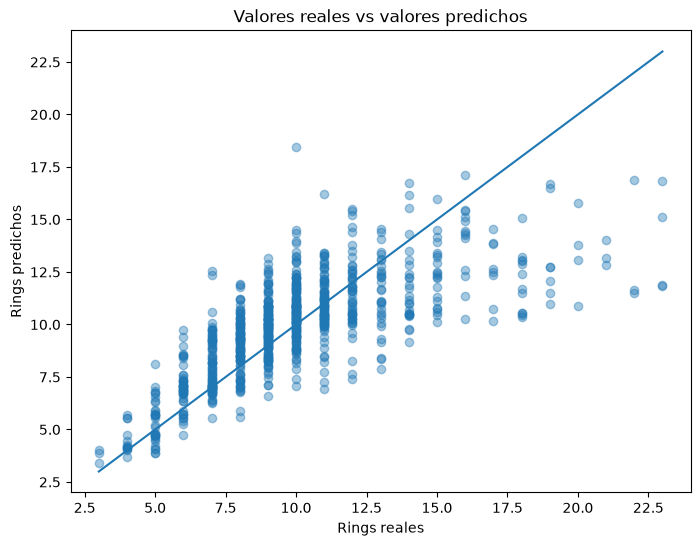

In [871]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.4
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.title("Valores reales vs valores predichos")
plt.xlabel("Rings reales")
plt.ylabel("Rings predichos")

plt.show()

**Conclusión:**  
El gráfico de valores reales frente a valores predichos muestra que el modelo reproduce razonablemente la tendencia general de `rings`, especialmente en los valores intermedios donde se concentra la mayor parte de los individuos.

Sin embargo, se observa una mayor dispersión a medida que aumenta el número real de anillos.

En particular, para individuos con valores elevados de `rings`, el modelo tiende a generar predicciones menores que los valores reales, lo que indica una tendencia a subestimar los casos con mayor número de anillos.

Este comportamiento sugiere que el modelo presenta mayor precisión en la región central de la distribución y mayor dificultad para predecir correctamente los valores extremos de `rings`.

### 10.6.3 Análisis de residuos

Para analizar con mayor detalle los errores del modelo, se calculan los residuos de las predicciones.

Un residuo representa la diferencia entre el valor real de `rings` y el valor predicho por el modelo.

- Un residuo cercano a 0 indica una predicción precisa.
- Un residuo positivo indica que el modelo subestimó el número de anillos.
- Un residuo negativo indica que el modelo sobreestimó el número de anillos.

El análisis de los residuos permite identificar posibles patrones sistemáticos en los errores del modelo.

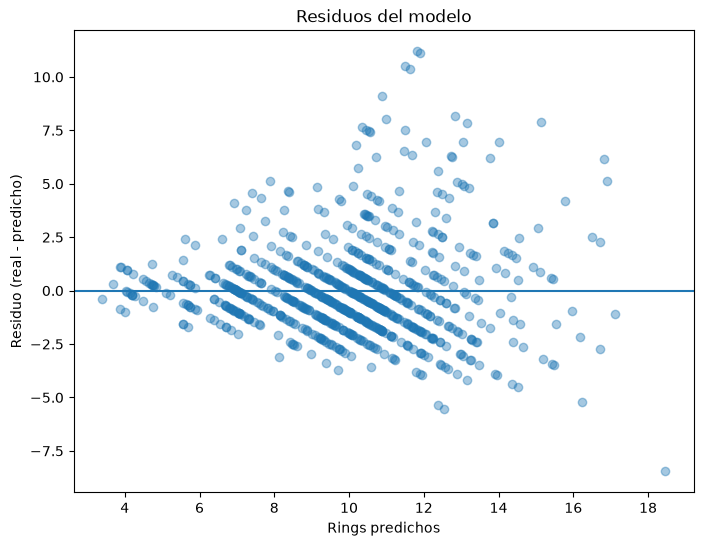

In [872]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0
)

plt.title("Residuos del modelo")
plt.xlabel("Rings predichos")
plt.ylabel("Residuo (real - predicho)")

plt.show()

**Conclusión:**  
El análisis de residuos muestra que una gran parte de las predicciones presenta errores relativamente cercanos a cero, especialmente en la región central de los valores predichos.

Sin embargo, también se observan residuos positivos de gran magnitud, lo que confirma que el modelo tiende a subestimar algunos individuos con valores elevados de `rings`.

La dispersión de los residuos aumenta en determinadas regiones, indicando que la precisión del modelo no es uniforme para todos los individuos.

Las bandas diagonales observadas se relacionan con el hecho de que `rings` toma valores enteros mientras que el modelo de regresión genera predicciones continuas.

En conjunto, el análisis confirma que Gradient Boosting captura adecuadamente la tendencia general del problema, aunque presenta mayores dificultades en algunos casos extremos.

### 10.7 Importancia de las variables

Luego de evaluar el desempeño del modelo seleccionado, se analiza la importancia de las variables utilizadas por Gradient Boosting.

Este análisis permite identificar qué características tuvieron mayor influencia en las decisiones predictivas del modelo.

La importancia de una variable refleja su utilidad dentro del modelo para reducir los errores de predicción, pero no implica necesariamente una relación causal con el número de anillos.

Debido a que el modelo forma parte de un pipeline, las variables deberán recuperarse después del preprocesamiento para asociar correctamente cada importancia con su característica correspondiente.

In [873]:
feature_names = gradient_boosting_model.named_steps[
    "preprocessor"
].get_feature_names_out()

print(feature_names)

['num__length' 'num__diameter' 'num__height' 'num__whole_weight'
 'num__shucked_weight' 'num__viscera_weight' 'num__shell_weight'
 'cat__sex_F' 'cat__sex_I' 'cat__sex_M']


In [874]:
feature_importances = gradient_boosting_model.named_steps[
    "model"
].feature_importances_

importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Importancia": feature_importances
})

importance_df = importance_df.sort_values(
    by="Importancia",
    ascending=False
).reset_index(drop=True)

importance_df

,Variable,Importancia
0,num__shell_weight,0.652740
1,num__shucked_weight,0.174746
2,num__height,0.052013
3,num__whole_weight,0.049297
4,num__diameter,0.022638
5,cat__sex_I,0.021733
6,num__length,0.012491
7,num__viscera_weight,0.011545
8,cat__sex_F,0.002757
9,cat__sex_M,0.000040


**Conclusión:**  
El análisis de importancia de variables muestra que `shell_weight` es la característica con mayor influencia en las predicciones realizadas por Gradient Boosting, con una importancia aproximada de 0.65.

La segunda variable más relevante es `shucked_weight` (≈ 0.17), mientras que `height` y `whole_weight` presentan contribuciones menores. Las restantes variables muestran importancias relativamente bajas dentro del modelo.

Este resultado es consistente con el análisis exploratorio, donde `shell_weight` presentó la mayor correlación lineal con `rings`.

Sin embargo, estas importancias deben interpretarse con precaución. Varias características físicas están fuertemente correlacionadas entre sí, por lo que pueden contener información redundante y el modelo puede concentrar la importancia en algunas de ellas.

Por lo tanto, la importancia predictiva de una variable no debe interpretarse como evidencia de causalidad biológica.

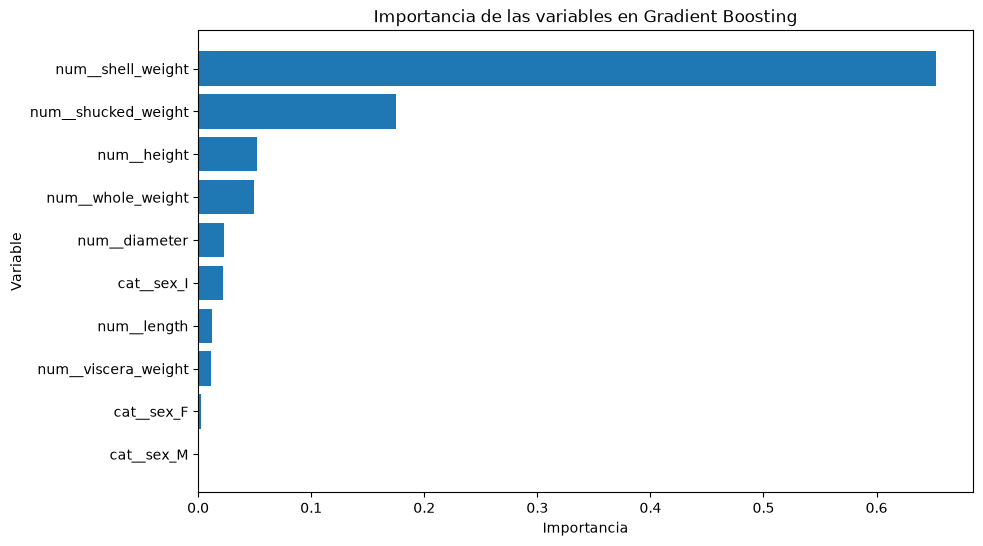

In [875]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Variable"],
    importance_df["Importancia"]
)

plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Importancia de las variables en Gradient Boosting")

plt.gca().invert_yaxis()

plt.show()

**Conclusión:**  
El gráfico de importancia de variables confirma que `shell_weight` es la característica con mayor influencia en las predicciones del modelo Gradient Boosting, seguida por `shucked_weight`.

Las demás variables presentan contribuciones considerablemente menores, aunque algunas como `height` y `whole_weight` también aportan información al modelo.

Este resultado refuerza lo observado previamente en la tabla de importancias y en el análisis exploratorio. Sin embargo, debido a la alta correlación existente entre varias características físicas, estas importancias deben interpretarse como relevancia predictiva dentro del modelo y no como evidencia de causalidad biológica.

## 11. Conclusiones del prototipo

El prototipo permitió desarrollar y validar un flujo completo de Data Science utilizando el dataset Abalone como caso de estudio biológico.

A lo largo del análisis se realizaron las siguientes etapas:

- carga y comprensión del dataset;
- evaluación de calidad y limpieza de datos;
- análisis exploratorio univariado y bivariado;
- identificación de la variable objetivo `rings`;
- separación de variables predictoras (`X`) y objetivo (`y`);
- división en conjuntos de entrenamiento y prueba;
- construcción de un pipeline de preprocesamiento;
- imputación de valores faltantes;
- codificación de la variable categórica `sex`;
- comparación de distintos modelos de regresión mediante validación cruzada;
- selección y evaluación final del mejor modelo;
- análisis de predicciones, residuos e importancia de variables.

Entre los modelos evaluados, Gradient Boosting presentó el mejor desempeño durante la validación cruzada, con un MAE promedio aproximado de **1.52 anillos**.

En el conjunto de prueba, el modelo obtuvo:

- **MAE:** ≈ 1.57 anillos
- **RMSE:** ≈ 2.25 anillos
- **R²:** ≈ 0.53

Los resultados indican que las características físicas disponibles permiten predecir parcialmente el número de anillos, aunque existe una proporción importante de variabilidad que el modelo no logra explicar.

El análisis de importancia de variables mostró que `shell_weight` fue la característica con mayor influencia predictiva dentro del modelo. Sin embargo, estas importancias deben interpretarse con precaución debido a la fuerte correlación existente entre varias variables físicas.

Este notebook constituye el prototipo funcional sobre el cual se desarrollará BioData Assistant (BioIA). En la siguiente etapa, la lógica utilizada será transformada en funciones y módulos reutilizables para permitir que el sistema pueda aplicar este flujo a otros datasets biológicos tabulares.